# **Análise de Sentimentos de Avaliações de Alimentação na Amazon**

**Grupo D:** Ewerton, João, Daniel, Miguel, Emilly

**Disciplina:** IBM3130 - Processamento de Linguagem Natural

## Introdução

O objetivo deste trabalho é classificar o sentimento (positivo ou negativo) de reviews de produtos alimentícios vendidos na Amazon, usando o dataset [Amazon Fine Food Reviews](https://www.kaggle.com/datasets/snap/amazon-fine-food-reviews).

**Sobre o dataset**

O conjunto reúne mais de 500.000 avaliações de alimentos feitas na Amazon entre 1999 e 2012. Cada review possui, entre outros campos, uma nota (`Score`, de 1 a 5) e o texto da avaliação (`Text`).

**Abordagem**

Seguiremos o mesmo pipeline visto em aula na análise de sentimentos do dataset Olist:

1. Carga e limpeza dos dados;
2. Construção do rótulo binário a partir da nota;
3. Pré-processamento do texto (minúsculas, regex, stopwords, lematização);
4. *Feature extraction* com Bag of Words e TF-IDF;
5. Treinamento e comparação de modelos: Regressão Logística, Naive Bayes e SVM;
6. Avaliação com acurácia, F1-Score e matriz de confusão;
7. Teste com novas frases.

# Pré-processamento

Importando as bibliotecas.

In [ ]:
import pandas as pd
import numpy as np
import re
import nltk
import spacy
import matplotlib.pyplot as plt
import seaborn as sns

## Carregando o dataset

O dataset está hospedado no Kaggle. No Colab, a forma mais simples de baixá-lo é com a biblioteca `kagglehub`, que já vem instalada. Usaremos o arquivo `Reviews.csv`.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("snap/amazon-fine-food-reviews")
print(path)

Using Colab cache for faster access to the 'amazon-fine-food-reviews' dataset.
/kaggle/input/amazon-fine-food-reviews


In [ ]:
data = pd.read_csv(path + "/Reviews.csv")
data.head()

,Id,ProductId,UserId,ProfileName,HelpfulnessNumerator,HelpfulnessDenominator,Score,Time,Summary,Text
0,1,B001E4KFG0,A3SGXH7AUHU8GW,delmartian,1,1,5,1303862400,Good Quality Dog Food,I have bought several of the Vitality canned d...
1,2,B00813GRG4,A1D87F6ZCVE5NK,dll pa,0,0,1,1346976000,Not as Advertised,Product arrived labeled as Jumbo Salted Peanut...
2,3,B000LQOCH0,ABXLMWJIXXAIN,"Natalia Corres ""Natalia Corres""",1,1,4,1219017600,"""Delight"" says it all",This is a confection that has been around a fe...
3,4,B000UA0QIQ,A395BORC6FGVXV,Karl,3,3,2,1307923200,Cough Medicine,If you are looking for the secret ingredient i...
4,5,B006K2ZZ7K,A1UQRSCLF8GW1T,"Michael D. Bigham ""M. Wassir""",0,0,5,1350777600,Great taffy,Great taffy at a great price. There was a wid...


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 568454 entries, 0 to 568453
Data columns (total 10 columns):
 #   Column                  Non-Null Count   Dtype 
---  ------                  --------------   ----- 
 0   Id                      568454 non-null  int64 
 1   ProductId               568454 non-null  object
 2   UserId                  568454 non-null  object
 3   ProfileName             568428 non-null  object
 4   HelpfulnessNumerator    568454 non-null  int64 
 5   HelpfulnessDenominator  568454 non-null  int64 
 6   Score                   568454 non-null  int64 
 7   Time                    568454 non-null  int64 
 8   Summary                 568427 non-null  object
 9   Text                    568454 non-null  object
dtypes: int64(5), object(5)
memory usage: 43.4+ MB


Como nosso foco é a análise de sentimentos, precisamos apenas das colunas `Score` e `Text`.

In [ ]:
data = data[['Score', 'Text']]
data.head()

,Score,Text
0,5,I have bought several of the Vitality canned d...
1,1,Product arrived labeled as Jumbo Salted Peanut...
2,4,This is a confection that has been around a fe...
3,2,If you are looking for the secret ingredient i...
4,5,Great taffy at a great price. There was a wid...


## Removendo duplicatas

Este dataset possui muitas avaliações repetidas, pois o mesmo review aparece associado a produtos diferentes (por exemplo, variações de sabor do mesmo item). Vamos verificar e remover as duplicatas com base no texto da avaliação.

In [ ]:
duplicados = round(sum(data.duplicated('Text')) / len(data) * 100, 2)
print(f"Reviews com texto duplicado: {duplicados}%.")

Reviews com texto duplicado: 30.76%.


In [ ]:
data.drop_duplicates('Text', inplace=True)
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393579 entries, 0 to 568453
Data columns (total 2 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Score   393579 non-null  int64 
 1   Text    393579 non-null  object
dtypes: int64(1), object(1)
memory usage: 9.0+ MB


## Montando a coluna de texto

Vamos usar apenas o corpo da avaliação (`Text`) como texto de entrada, renomeando-o para `review`, e remover entradas sem texto.

In [ ]:
data['review'] = data['Text']

# Removendo entradas sem texto
data = data[data['review'].str.strip() != '']
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 393579 entries, 0 to 568453
Data columns (total 3 columns):
 #   Column  Non-Null Count   Dtype 
---  ------  --------------   ----- 
 0   Score   393579 non-null  int64 
 1   Text    393579 non-null  object
 2   review  393579 non-null  object
dtypes: int64(1), object(2)
memory usage: 12.0+ MB


## Construindo o rótulo (variável alvo)

In [ ]:
data['Score'].value_counts()

,count
Score,
5,250716
4,56042
1,36275
3,29754
2,20792


A coluna `Score` tem notas de 1 (pior) a 5 (melhor). Para transformar o problema em uma classificação binária, seguiremos o mesmo critério usado em aula:

- `Score` maior que 3: review positiva (1);
- `Score` menor ou igual a 3: review negativa (0).

In [ ]:
labels = []

for score in data['Score']:
  if score > 3:
    labels.append(1)
  else:
    labels.append(0)

data['label'] = labels
data.head(10)

,Score,Text,review,label
0,5,I have bought several of the Vitality canned d...,I have bought several of the Vitality canned d...,1
1,1,Product arrived labeled as Jumbo Salted Peanut...,Product arrived labeled as Jumbo Salted Peanut...,0
2,4,This is a confection that has been around a fe...,This is a confection that has been around a fe...,1
3,2,If you are looking for the secret ingredient i...,If you are looking for the secret ingredient i...,0
4,5,Great taffy at a great price. There was a wid...,Great taffy at a great price. There was a wid...,1
5,4,I got a wild hair for taffy and ordered this f...,I got a wild hair for taffy and ordered this f...,1
6,5,This saltwater taffy had great flavors and was...,This saltwater taffy had great flavors and was...,1
7,5,This taffy is so good. It is very soft and ch...,This taffy is so good. It is very soft and ch...,1
8,5,Right now I'm mostly just sprouting this so my...,Right now I'm mostly just sprouting this so my...,1
9,5,This is a very healthy dog food. Good for thei...,This is a very healthy dog food. Good for thei...,1


Verificando o balanceamento da base.

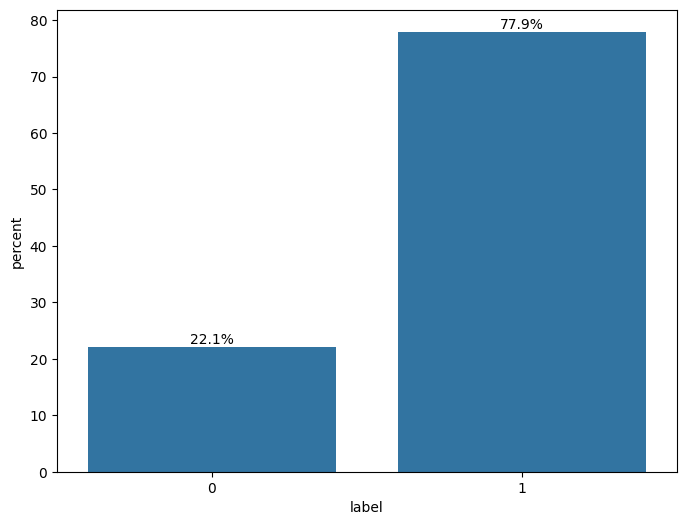

In [ ]:
plt.figure(figsize=(8,6))
ax = sns.countplot(x='label', data=data, stat="percent")

for p in ax.patches:
    percentage = '{:.1f}%'.format(p.get_height())
    x = p.get_x() + p.get_width() / 2
    y = p.get_height()
    ax.annotate(percentage, (x, y), ha='center', va='bottom')
plt.show()

A base é bem desbalanceada: cerca de 3/4 das avaliações são positivas. Isso é esperado em e-commerce, mas exige atenção na avaliação dos modelos. Por isso, além da acurácia, usaremos também o F1-Score e a matriz de confusão, que mostram se o modelo está acertando também a classe minoritária (negativa).

## Amostragem

O dataset completo tem quase 400.000 reviews após a limpeza, o que tornaria a lematização e o treinamento muito demorados no Colab. Vamos trabalhar com uma amostra aleatória de 50.000 reviews, tamanho próximo ao usado no exemplo do Olist e suficiente para treinar bons modelos.

In [ ]:
data = data.sample(n=50000, random_state=10).reset_index(drop=True)
data['label'].value_counts(normalize=True)

,proportion
label,
1,0.78112
0,0.21888


## Pré-processamento do texto

As etapas são as mesmas vistas em aula:

- Normalização para minúsculas;
- Filtrar apenas letras (removendo pontuações, números, símbolos e tags HTML, comuns neste dataset);
- Remover stopwords;
- Lematizar.

Para as stopwords, usaremos a lista de inglês da biblioteca `nltk`.

In [ ]:
nltk.download('stopwords')
from nltk.corpus import stopwords

stopwords_en = stopwords.words("english")
print(stopwords_en)

['a', 'about', 'above', 'after', 'again', 'against', 'ain', 'all', 'am', 'an', 'and', 'any', 'are', 'aren', "aren't", 'as', 'at', 'be', 'because', 'been', 'before', 'being', 'below', 'between', 'both', 'but', 'by', 'can', 'couldn', "couldn't", 'd', 'did', 'didn', "didn't", 'do', 'does', 'doesn', "doesn't", 'doing', 'don', "don't", 'down', 'during', 'each', 'few', 'for', 'from', 'further', 'had', 'hadn', "hadn't", 'has', 'hasn', "hasn't", 'have', 'haven', "haven't", 'having', 'he', "he'd", "he'll", 'her', 'here', 'hers', 'herself', "he's", 'him', 'himself', 'his', 'how', 'i', "i'd", 'if', "i'll", "i'm", 'in', 'into', 'is', 'isn', "isn't", 'it', "it'd", "it'll", "it's", 'its', 'itself', "i've", 'just', 'll', 'm', 'ma', 'me', 'mightn', "mightn't", 'more', 'most', 'mustn', "mustn't", 'my', 'myself', 'needn', "needn't", 'no', 'nor', 'not', 'now', 'o', 'of', 'off', 'on', 'once', 'only', 'or', 'other', 'our', 'ours', 'ourselves', 'out', 'over', 'own', 're', 's', 'same', 'shan', "shan't", 'she

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


Na lista constam palavras de negação como `not`, `no` e `nor` que, se removidas, podem inverter o sentimento de uma frase (por exemplo, "not good"). Vamos mantê-las no texto, como fizemos com `não` e `nem` no caso do português.

In [ ]:
stopwords_en.remove('not')
stopwords_en.remove('no')
stopwords_en.remove('nor')

Para a lematização, usaremos o modelo de inglês da biblioteca spaCy, o `en_core_web_sm`. Vamos desabilitar os componentes `parser` e `ner`, que não são necessários para lematizar, deixando o processamento mais rápido.

In [ ]:
spacy.cli.download("en_core_web_sm")

✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [ ]:
spc_en = spacy.load("en_core_web_sm", disable=["parser", "ner"])

A função abaixo recebe uma string, remove tags HTML, deixa tudo em minúsculo, filtra apenas letras e retira as stopwords.

A lematização será feita em seguida com o `nlp.pipe` do spaCy, que processa os textos em lote e é bem mais rápido do que chamar o modelo texto a texto.

In [ ]:
def limpa_texto(texto):
  # Remove tags HTML (ex: <br />), comuns neste dataset
  texto = re.sub(r"<[^>]+>", " ", texto)

  texto = texto.lower()

  # Mantem apenas letras
  texto = re.sub(r"[\W\d_]+", " ", texto)

  # Remove stopwords
  texto = [pal for pal in texto.split() if pal not in stopwords_en]

  return " ".join(texto)

In [ ]:
data['review'] = data['review'].apply(limpa_texto)
data.head()

,Score,Text,review,label
0,5,Love this product and will never buy another l...,love product never buy another liquid smoke pr...,1
1,4,This is a mayo my hubby and I can agree on. I...,mayo hubby agree prefer cheaper stuff trader j...,1
2,5,"Like the other coffee drink I tried, I wasn't ...",like coffee drink tried sure expect time worry...,1
3,3,Nutrition -- If you're already saddled with Ce...,nutrition already saddled celiac disease dieta...,0
4,3,That's not a compliment. Maxwell House isn't e...,not compliment maxwell house exactly top shelf...,0


In [ ]:
# Lematizacao em lote com o spaCy (demora alguns minutos)
reviews_lematizadas = []

for doc in spc_en.pipe(data['review'], batch_size=1000):
  reviews_lematizadas.append(" ".join([token.lemma_ for token in doc]))

data['review'] = reviews_lematizadas
data.head(10)

,Score,Text,review,label
0,5,Love this product and will never buy another l...,love product never buy another liquid smoke pr...,1
1,4,This is a mayo my hubby and I can agree on. I...,mayo hubby agree prefer cheap stuff trader joe...,1
2,5,"Like the other coffee drink I tried, I wasn't ...",like coffee drink try sure expect time worry w...,1
3,3,Nutrition -- If you're already saddled with Ce...,nutrition already saddle celiac disease dietar...,0
4,3,That's not a compliment. Maxwell House isn't e...,not compliment maxwell house exactly top shelf...,0
5,5,"After scouring the web, this offering from Ama...",scour web offer amazon cheap one pound cardamo...,1
6,5,I take 5 a day and will update when my bloodwo...,take day update bloodwork do hop good taste we...,1
7,5,It is organic--Love. It doesn't have to be re...,organic love refrigerate love easy travel love...,1
8,5,These olives were an impulse buy. I was very ...,olives impulse buy surprised receive sooo tast...,1
9,5,This tea is great hot or cold. I like mine col...,tea great hot cold like mine cold spenda take ...,1


Como algumas avaliações tinham apenas números ou símbolos, podem ter sobrado textos vazios. Vamos removê-los.

In [ ]:
data = data[data['review'].str.strip() != '']
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Score   50000 non-null  int64 
 1   Text    50000 non-null  object
 2   review  50000 non-null  object
 3   label   50000 non-null  int64 
dtypes: int64(2), object(2)
memory usage: 1.5+ MB


In [ ]:
# Execute essa celula se quiser salvar o dataset pre-processado
data.to_csv('amazon_food_preprocessado.csv', index=False, columns=['review', 'label'])

## *Feature extraction*

Essa etapa transforma o texto em vetores numéricos. Vamos usar as duas técnicas clássicas vistas em aula, com a biblioteca Scikit-Learn.

### *Bag of Words*

O `CountVectorizer` representa cada texto como um vetor de ocorrência de palavras. Com `binary=True`, o vetor indica apenas presença (1) ou ausência (0) da palavra. O `max_features=5000` limita o vocabulário às 5.000 palavras mais frequentes.

In [ ]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer(binary=True, max_features=5000)

texto = data['review']

X_bow = vectorizer.fit_transform(texto)

### TF-IDF

O `TfidfVectorizer` atribui a cada palavra uma pontuação que mede sua importância no texto, penalizando palavras muito comuns no corpus.

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf_vect = TfidfVectorizer(max_features=5000)

X_tfidf = tfidf_vect.fit_transform(texto)

# Modelos

Dividindo os dados em base de treino e teste (70-30).

In [ ]:
from sklearn.model_selection import train_test_split

# Texto vetorizado com BoW
X1_train, X1_test, y1_train, y1_test = train_test_split(X_bow, data['label'],
                                                        test_size=0.3, random_state=10)

# Texto vetorizado com TF-IDF
X2_train, X2_test, y2_train, y2_test = train_test_split(X_tfidf, data['label'],
                                                        test_size=0.3, random_state=10)

Importando as métricas e definindo a função de avaliação dos modelos.

In [ ]:
from sklearn.metrics import accuracy_score, confusion_matrix, f1_score, ConfusionMatrixDisplay

def mostra_metricas(y_true, y_pred):
  print("Acurácia: ", accuracy_score(y_true, y_pred))
  print("\nF1-Score:", f1_score(y_true, y_pred, average='weighted'))
  print("\nMatriz de confusão:")
  cm = confusion_matrix(y_true, y_pred)
  cm_disp = ConfusionMatrixDisplay(confusion_matrix=cm)
  cm_disp.plot()
  plt.show()

In [ ]:
# Dicionario para guardar a acuracia de cada combinacao modelo + vetorizacao
resultados = {}

## Regressão Logística

### Texto vetorizado com *Bag of Words*

Acurácia:  0.8646666666666667

F1-Score: 0.8605037639250734

Matriz de confusão:


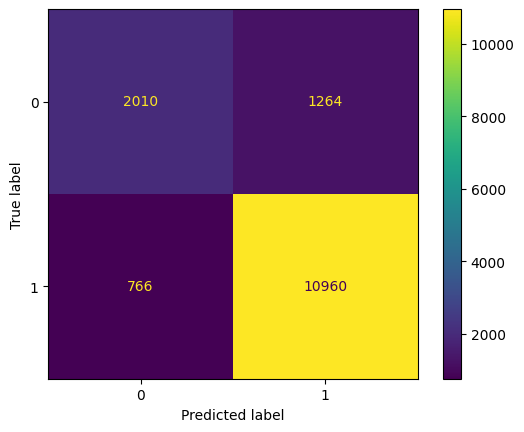

In [ ]:
from sklearn.linear_model import LogisticRegression

reglog = LogisticRegression(max_iter=1000)

reglog.fit(X1_train, y1_train)

y1_reglog_pred = reglog.predict(X1_test)

resultados['Reg. Logística + BoW'] = accuracy_score(y1_test, y1_reglog_pred)
mostra_metricas(y1_test, y1_reglog_pred)

### Texto vetorizado com TF-IDF

Acurácia:  0.871

F1-Score: 0.8620902233729202

Matriz de confusão:


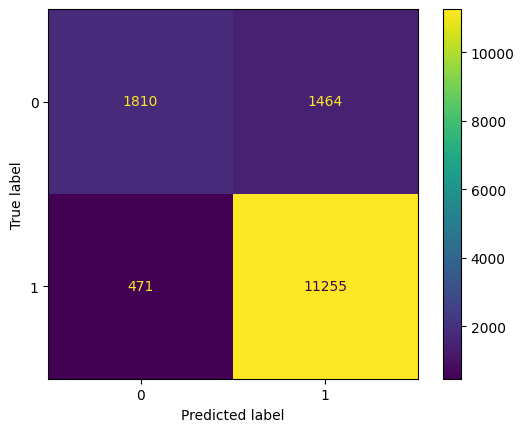

In [ ]:
reglog2 = LogisticRegression(max_iter=1000)

reglog2.fit(X2_train, y2_train)

y2_reglog_pred = reglog2.predict(X2_test)

resultados['Reg. Logística + TF-IDF'] = accuracy_score(y2_test, y2_reglog_pred)
mostra_metricas(y2_test, y2_reglog_pred)

## Naive Bayes

O Naive Bayes é um dos algoritmos clássicos para classificação de textos citados em aula. Usaremos a versão `MultinomialNB`, adequada para contagens de palavras.

### Texto vetorizado com *Bag of Words*

Acurácia:  0.8596

F1-Score: 0.8583173935204401

Matriz de confusão:


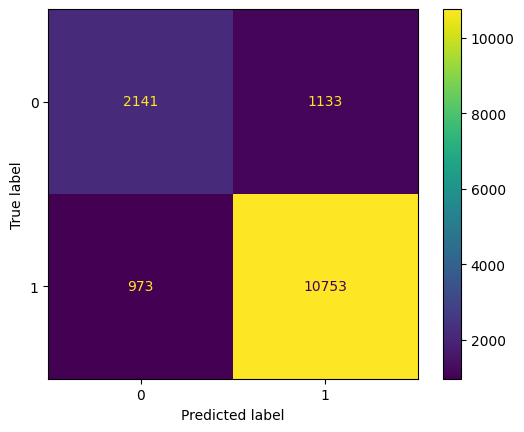

In [ ]:
from sklearn.naive_bayes import MultinomialNB

nb = MultinomialNB()

nb.fit(X1_train, y1_train)

y1_nb_pred = nb.predict(X1_test)

resultados['Naive Bayes + BoW'] = accuracy_score(y1_test, y1_nb_pred)
mostra_metricas(y1_test, y1_nb_pred)

### Texto vetorizado com TF-IDF

Acurácia:  0.8207333333333333

F1-Score: 0.7735188353775093

Matriz de confusão:


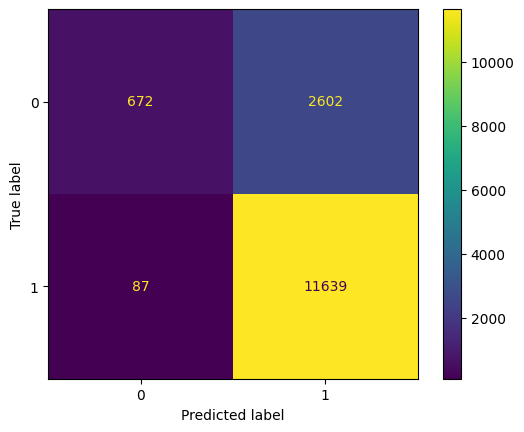

In [ ]:
nb2 = MultinomialNB()

nb2.fit(X2_train, y2_train)

y2_nb_pred = nb2.predict(X2_test)

resultados['Naive Bayes + TF-IDF'] = accuracy_score(y2_test, y2_nb_pred)
mostra_metricas(y2_test, y2_nb_pred)

## SVM

O SVM também foi citado em aula como um dos algoritmos mais usados para classificação de textos. Usaremos o `LinearSVC`, a versão linear do SVM, que é rápida e funciona bem com vetores esparsos de texto.

### Texto vetorizado com *Bag of Words*

Acurácia:  0.8493333333333334

F1-Score: 0.8471746864930377

Matriz de confusão:


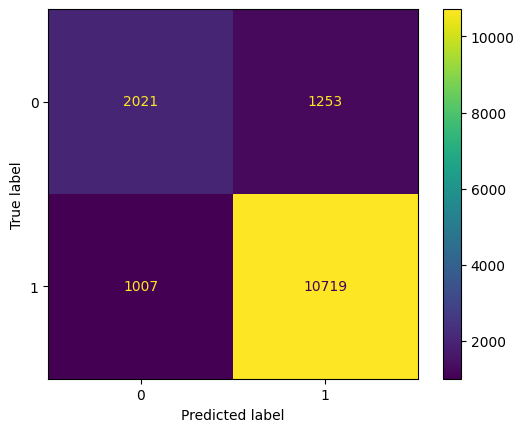

In [ ]:
from sklearn.svm import LinearSVC

svm = LinearSVC()

svm.fit(X1_train, y1_train)

y1_svm_pred = svm.predict(X1_test)

resultados['SVM + BoW'] = accuracy_score(y1_test, y1_svm_pred)
mostra_metricas(y1_test, y1_svm_pred)

### Texto vetorizado com TF-IDF

Acurácia:  0.8688666666666667

F1-Score: 0.8647876620607395

Matriz de confusão:


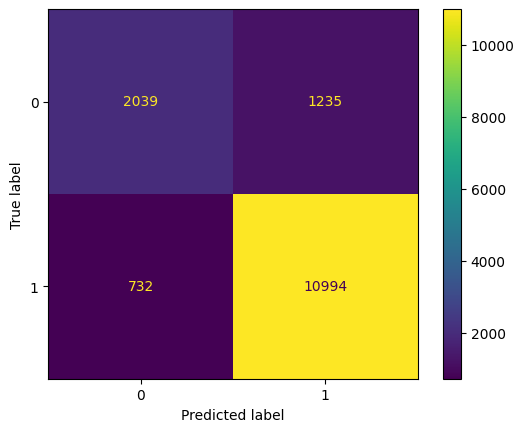

In [ ]:
svm2 = LinearSVC()

svm2.fit(X2_train, y2_train)

y2_svm_pred = svm2.predict(X2_test)

resultados['SVM + TF-IDF'] = accuracy_score(y2_test, y2_svm_pred)
mostra_metricas(y2_test, y2_svm_pred)

# Comparação dos modelos

Resumindo a acurácia de todas as combinações de modelo e vetorização.

In [ ]:
comparacao = pd.DataFrame(resultados.items(), columns=['Modelo', 'Acurácia'])
comparacao = comparacao.sort_values(by='Acurácia', ascending=False).reset_index(drop=True)
comparacao

,Modelo,Acurácia
0,Reg. Logística + TF-IDF,0.871000
1,SVM + TF-IDF,0.868867
2,Reg. Logística + BoW,0.864667
3,Naive Bayes + BoW,0.859600
4,SVM + BoW,0.849333
5,Naive Bayes + TF-IDF,0.820733


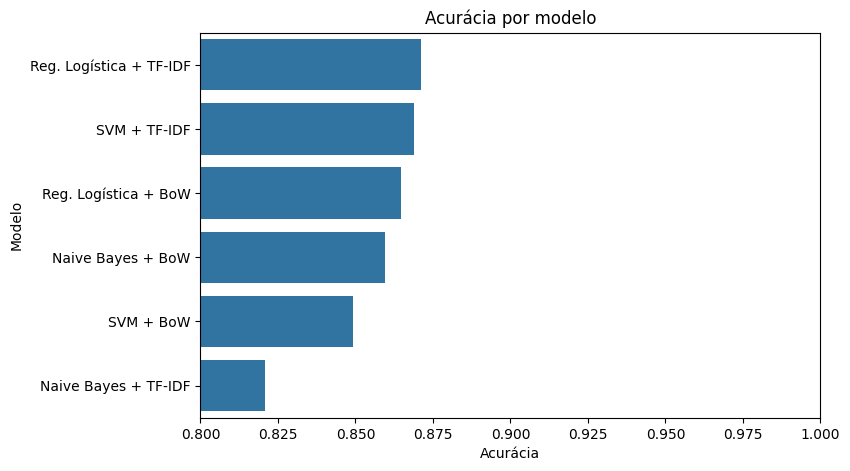

In [ ]:
plt.figure(figsize=(8,5))
ax = sns.barplot(y='Modelo', x='Acurácia', data=comparacao)
plt.xlim(0.8, 1.0)
plt.title('Acurácia por modelo')
plt.show()

# Resultados

Para terminar, vamos avaliar como o modelo atua em novos textos, simulando novas avaliações com a combinação que performou melhor (Regressão Logística com TF-IDF).

In [ ]:
def nova_predicao(texto):
  texto_limpo = limpa_texto(texto)
  texto_vetorizado = tfidf_vect.transform([texto_limpo])
  pred = reglog2.predict(texto_vetorizado)

  if pred == 0:
    print("Essa é uma review negativa.")
  else:
    print("Essa é uma review positiva.")

In [ ]:
nova_predicao("This is the best coffee I have ever tasted, I will definitely buy it again")

Essa é uma review positiva.


In [ ]:
nova_predicao("The chips arrived stale and the package was damaged, total waste of money")

Essa é uma review negativa.


In [ ]:
nova_predicao("Not good at all, my dog refused to eat it")

Essa é uma review positiva.


In [ ]:
nova_predicao("Tastes amazing and the delivery was fast")

Essa é uma review positiva.


In [ ]:
nova_predicao("I did not like the flavor, too sweet for me")

Essa é uma review negativa.


In [ ]:
nova_predicao("Despite the slow delivery, the cookies were delicious!")

Essa é uma review positiva.


# Conclusão

Neste trabalho classificamos o sentimento de reviews de alimentos da Amazon seguindo o pipeline clássico de NLP visto em aula: limpeza e lematização do texto, vetorização com Bag of Words e TF-IDF e treinamento de três algoritmos supervisionados (Regressão Logística, Naive Bayes e SVM).

Principais observações:

- A vetorização com TF-IDF tende a produzir resultados iguais ou melhores que o Bag of Words binário, em linha com o que observamos no exemplo do Olist;
- A Regressão Logística e o SVM linear apresentam desempenho muito próximo, ambos acima do Naive Bayes;
- Manter as palavras de negação (`not`, `no`, `nor`) fora da lista de stopwords foi importante para o modelo distinguir frases como "good" e "not good";
- Como a base é desbalanceada (cerca de 3/4 das reviews são positivas), a matriz de confusão mostra que os erros se concentram na classe negativa. Um próximo passo seria tratar esse desbalanceamento, ou ainda testar abordagens mais avançadas, como word embeddings (Word2Vec) ou modelos baseados em Transformers (BERT), vistos nas aulas seguintes.